# Four-hour performance deterioration with stable workforce FTE

## tl;dr

Two providers in the defined 20-provider London cohort met both screening criteria: workforce FTE within ±3.5% between April 2024 and March 2025, and four-hour performance at least 2.0 percentage points lower. Epsom and St Helier showed an observed combination of slightly lower estimated availability and higher end-period activity. Hillingdon's deterioration was not explained by aggregate workforce size or total attendance volume alone. This notebook identifies observed patterns for operational follow-up; it does not establish causality.

## Context & Methods

**Question:** Why did some providers experience deteriorating four-hour performance despite broadly stable workforce FTE?

**Scope:** April 2024–March 2025; the project’s approved 20-provider London cohort; aggregate public NHS data only.

### Key assumptions

- Workforce is aggregated from staff-group level to organisation-month before joining to absence and A&E facts.
- Estimated available FTE = Workforce FTE × (1 − sickness absence rate). It is an analytical proxy, not rostered capacity.
- A provider is selected only if April-to-March FTE is within ±3.5% and four-hour performance changes by −2.0 percentage points or worse.
- The Q1-to-Q4 comparison is a sensitivity check; it does not prove a causal mechanism.

## Data

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import SVG, display

repo_root = Path.cwd().resolve()
if not (repo_root / '02_source_data').exists():
    repo_root = repo_root.parent
analysis_dir = repo_root / '08_ad_hoc_analysis'
sys.path.insert(0, str(analysis_dir))

from analyse_four_hour_performance import (
    build_model, create_candidate_summary, create_selection_table, create_trend_chart
)

print(f'Repository: {repo_root}')
print('Sources: workforce reporting extract, sickness-absence CSVs, A&E activity CSVs, and approved organisation reference.')

Repository: C:\Users\wldbs\OneDrive\바탕화면\Works\project6
Sources: workforce reporting extract, sickness-absence CSVs, A&E activity CSVs, and approved organisation reference.


## Results

### 1. Build the organisation-month analytical model

In [2]:
model = build_model()
selection = create_selection_table(model)
selected_codes = selection.loc[selection['SelectedForReview'], 'OrganisationCode'].tolist()
candidates = create_candidate_summary(model, selected_codes)

print(f'Organisation-month observations: {len(model):,}')
print(f'Providers selected for review: {len(selected_codes)}')
selection[[
    'OrganisationCode', 'CanonicalOrganisationName', 'FTEChangePct',
    'FourHourPerformanceChangePP', 'StableFTE', 'DeterioratingPerformance', 'SelectedForReview'
]].round({'FTEChangePct': 2, 'FourHourPerformanceChangePP': 2})

Organisation-month observations: 240
Providers selected for review: 2


,OrganisationCode,CanonicalOrganisationName,FTEChangePct,FourHourPerformanceChangePP,StableFTE,DeterioratingPerformance,SelectedForReview
4,RAS,Hillingdon Hospitals NHS Foundation Trust,3.01,-3.27,True,True,True
17,RVR,Epsom and St Helier University Hospitals NHS T...,-0.70,-2.24,True,True,True
14,RQM,Chelsea and Westminster Hospital NHS Foundatio...,4.88,-1.83,False,False,False
19,RYX,Central London Community Healthcare NHS Trust,2.74,-0.74,True,False,False
15,RQX,Homerton Healthcare NHS Foundation Trust,2.70,-0.45,True,False,False
18,RYJ,Imperial College Healthcare NHS Trust,5.16,-0.33,False,False,False
12,RKE,Whittington Health NHS Trust,4.67,0.06,False,False,False
13,RP6,Moorfields Eye Hospital NHS Foundation Trust,7.37,0.23,False,False,False
6,RF4,"Barking, Havering and Redbridge University Hos...",4.85,0.24,False,False,False
8,RJ2,Lewisham and Greenwich NHS Trust,2.94,1.07,True,False,False


### 2. Examine the selected providers

In [3]:
driver_columns = [
    'Organisation', 'WorkforceFTEChangePct', 'FourHourPerformanceChangePP',
    'SicknessAbsenceChangePP', 'EstimatedAvailableFTEChangePct',
    'AttendanceChangePct', 'EmergencyAdmissionsChangePct',
    'AttendancesOverFourHoursChangePct', 'Waits12PlusHoursDTAChangePct'
]
candidates[driver_columns].round(2)

,Organisation,WorkforceFTEChangePct,FourHourPerformanceChangePP,SicknessAbsenceChangePP,EstimatedAvailableFTEChangePct,AttendanceChangePct,EmergencyAdmissionsChangePct,AttendancesOverFourHoursChangePct,Waits12PlusHoursDTAChangePct
0,Hillingdon Hospitals NHS Foundation Trust,3.01,-3.27,0.92,2.02,6.13,-30.77,22.69,331.25
1,Epsom and St Helier University Hospitals NHS T...,-0.70,-2.24,0.15,-0.86,4.39,4.25,14.30,8.45


### 3. Inspect the monthly performance pattern

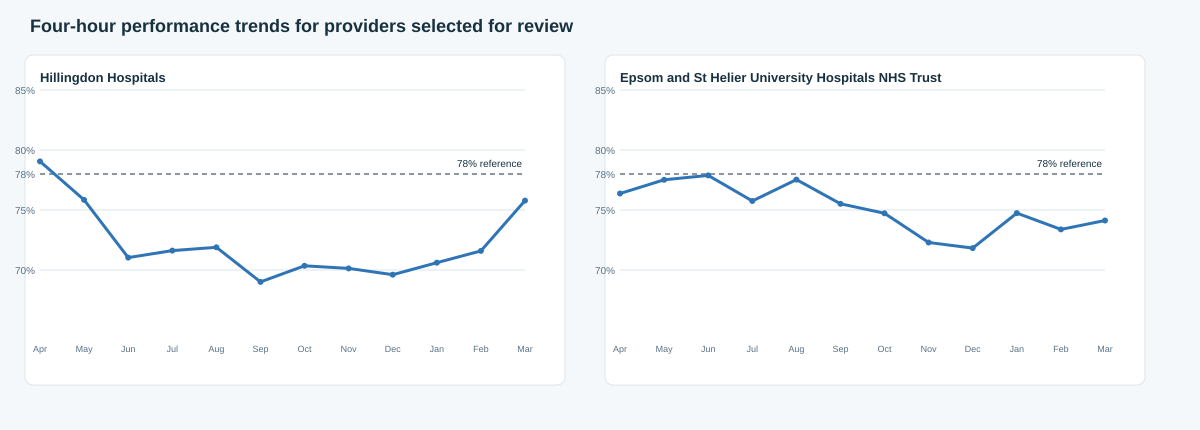

In [4]:
create_trend_chart(model, selected_codes)
display(SVG(filename=str(analysis_dir / 'outputs' / 'four_hour_performance_trends.svg')))

## Takeaways

- **Epsom and St Helier:** higher sickness absence, slightly lower estimated available FTE and higher end-period activity coincided with lower four-hour performance. Treat availability pressure as a plausible discussion point, not a proven cause.
- **Hillingdon:** four-hour performance deteriorated despite slightly higher FTE and estimated availability. The public aggregate data does not explain the change through workforce size or total attendances alone.
- **Recommended follow-up:** review shift-level rota fill, staff mix, acuity, bed availability, discharge flow and local operational changes.

The full narrative and caveats are documented in `four_hour_performance_investigation.md`.